# Trajectory validation: JAX `dqgs` vs original `qgs`

This notebook validates the differentiable JAX tendency (`dqgs`) against the
original `qgs` MAOOAM model at the level that matters scientifically: **integrate
the same initial condition, with the same parameters and timestep, through the
same RK4 scheme in both codes and compare the trajectories.** This is layer 2 of
`docs/agent/validation.md`.

Expectation (from `validation.md`): with matched IC / `dt` / RK4, the trajectory
error stays near **float64 round-off** over a short window, then grows as the
chaotic dynamics amplify round-off differences (a Lyapunov effect, not a bug).

Pipeline:
1. Quick pointwise tendency check (layer 1) so any later divergence is localized.
2. Short-window trajectory comparison (round-off regime).
3. Long-window comparison (expected chaotic divergence).
4. `write_steps` cross-check.


## 1. Setup

Enable float64 **before** any JAX array work, then import both codes and the on-attractor initial condition.

In [2]:
import os
import numpy as np

import jax
jax.config.update("jax_enable_x64", True)  # must precede any jax array creation
import jax.numpy as jnp

# dqgs: the differentiable JAX model under test
from dqgs import tendency, integrate, DEFAULT_PARAM_VECTOR, require_x64
require_x64()

# qgs: the reference implementation
from qgs.params.params import QgParams
from qgs.functions.tendencies import create_tendencies
from qgs.integrators.integrate import integrate_runge_kutta

# On-attractor initial condition (de Cruz active attractor), shape (36,)
ic = np.load(os.path.join("..", "configs", "ic", "de_cruz_active_ic.npy"))
print("IC shape:", ic.shape, "| state dim:", DEFAULT_PARAM_VECTOR.shape)

IC shape: (36,) | state dim: (16,)


## 2. Build the qgs reference tendency

Construct the `QgParams` object with **exactly** the configuration used to export
the symbolic tendency (`configs/create_tendencies_nonfixed_params.py`): atmosphere
2-2, ocean 2-4, the MAOOAM parameter set. `create_tendencies` returns a
numba-jitted `f(t, x)` (autonomous, so `t` is ignored) over the same 36-D state as
`dqgs` (the `eta_0=1` dummy is folded in by both).

In [3]:
model_parameters = QgParams()
model_parameters.set_atmospheric_channel_fourier_modes(2, 2)
model_parameters.set_oceanic_basin_fourier_modes(2, 4)
model_parameters.set_params({'kd': 0.0290, 'kdp': 0.0290, 'n': 1.5, 'r': 1.e-7,
                             'h': 136.5, 'd': 1.1e-7})
model_parameters.atemperature_params.set_params({'eps': 0.7, 'T0': 289.3,
                                                  'hlambda': 15.06})
model_parameters.gotemperature_params.set_params({'gamma': 5.6e8, 'T0': 301.46})
model_parameters.atemperature_params.set_insolation(103.3333, 0)
model_parameters.gotemperature_params.set_insolation(310, 0)

f_qgs, _ = create_tendencies(model_parameters)
print("qgs ndim:", model_parameters.ndim, "| f_qgs(0, ic) shape:", f_qgs(0.0, ic).shape)

qgs ndim: 36 | f_qgs(0, ic) shape: (36,)


## 3. Layer 1 — pointwise tendency check

Before integrating, confirm the two right-hand sides agree at several states (the
IC and a few random perturbations of it). They match to ~1e-17 (machine
precision), so the parameters and algebra agree and any trajectory divergence
later is attributable to integration (round-off accumulation), not a tendency
mismatch.

`dqgs.tendency` takes the full parameter vector; we use `DEFAULT_PARAM_VECTOR`,
which was read from the same config as the qgs model above.

In [4]:
rng = np.random.default_rng(0)
states = [ic] + [ic + 0.02 * rng.standard_normal(ic.shape) for _ in range(5)]

print(f"{'state':>8s}   max|dqgs - qgs|")
worst = 0.0
for i, U in enumerate(states):
    d_jax = np.asarray(tendency(jnp.asarray(U), DEFAULT_PARAM_VECTOR))
    d_qgs = f_qgs(0.0, U)
    e = np.max(np.abs(d_jax - d_qgs))
    worst = max(worst, e)
    print(f"{('ic' if i==0 else f'pert{i}'):>8s}   {e:.3e}")
print(f"\nworst tendency error: {worst:.3e}  (expected ~1e-13)")
assert worst < 1e-10, "tendency mismatch -- fix before trusting trajectories"


   state   max|dqgs - qgs|
      ic   7.806e-18
   pert1   9.541e-18
   pert2   7.373e-18
   pert3   1.561e-17
   pert4   1.561e-17
   pert5   1.648e-17

worst tendency error: 1.648e-17  (expected ~1e-13)


## 4. Short-window trajectory comparison (round-off regime)

Integrate both codes from `ic` with `dt = 0.1` for `N = 100` steps (`T = 10`).
Choosing an integer number of steps makes the qgs time grid `[0, dt, ..., N*dt]`
align exactly with the JAX grid.

- **qgs**: `integrate_runge_kutta(f_qgs, 0., T, dt, ic, write_steps=1)` → `(36, N+1)`.
- **dqgs**: `integrate(f_dqgs, ic, dt, N)` → `(N+1, 36)`, where `f_dqgs` is the
  unary closure `lambda U: tendency(U, DEFAULT_PARAM_VECTOR)`.

We transpose the qgs output to `(N+1, 36)` to compare.

In [11]:
dt = 0.1
N = 100
T = N * dt

# qgs reference trajectory -> (36, N+1) -> (N+1, 36)
t_qgs, traj_qgs = integrate_runge_kutta(f_qgs, 0.0, T, dt, ic, write_steps=1)
traj_qgs = np.asarray(traj_qgs).T

# dqgs trajectory
f_dqgs = lambda U: tendency(U, DEFAULT_PARAM_VECTOR)
traj_jax = np.asarray(integrate(f_dqgs, jnp.asarray(ic), dt, N))

print("qgs traj:", traj_qgs.shape, "| jax traj:", traj_jax.shape)

abs_err = np.abs(traj_jax - traj_qgs)
max_err_per_step = abs_err.max(axis=1)
rms_err_per_step = np.sqrt((abs_err ** 2).mean(axis=1))
print(f"max error over short window (T={T}): {max_err_per_step.max():.3e}")
print(f"final-step max error:                {max_err_per_step[-1]:.3e}")

qgs traj: (101, 36) | jax traj: (101, 36)
max error over short window (T=10.0): 9.194e-17
final-step max error:                9.194e-17


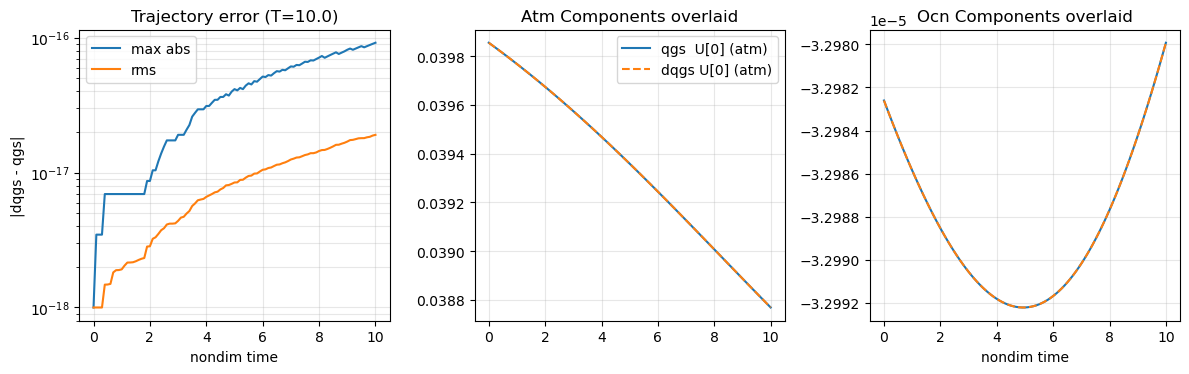

In [12]:
import matplotlib.pyplot as plt

time = np.arange(N + 1) * dt

fig, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(12, 4))

ax0.semilogy(time, np.maximum(max_err_per_step, 1e-18), label="max abs")
ax0.semilogy(time, np.maximum(rms_err_per_step, 1e-18), label="rms")
ax0.set_xlabel("nondim time"); ax0.set_ylabel("|dqgs - qgs|")
ax0.set_title(f"Trajectory error (T={T})"); ax0.legend(); ax0.grid(True, which="both", alpha=0.3)

ax1.plot(time, traj_qgs[:, 0], label="qgs  U[0] (atm)")
ax1.plot(time, traj_jax[:, 0], "--", label="dqgs U[0] (atm)")
ax2.set_xlabel("nondim time"); ax1.set_title("Atm Components overlaid"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(time, traj_qgs[:, 20], label="qgs  U[20] (ocean)")
ax2.plot(time, traj_jax[:, 20], "--", label="dqgs U[20] (ocean)")
ax2.set_xlabel("nondim time"); ax2.set_title("Ocn Components overlaid"); ax1.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout(); plt.show()

On a short window the error sits at float64 round-off (here ~1e-16) and the
overlaid components are visually indistinguishable — the JAX RK4 step reproduces
the qgs step term-for-term.

## 5. Long-window comparison (expected chaotic divergence)

MAOOAM is chaotic, so tiny round-off differences grow roughly exponentially. Over
a long window the trajectories *must* eventually separate; per `validation.md`
this is a scientific expectation, **not** a validation failure. We integrate for
`T = 1000` and plot the error growth.

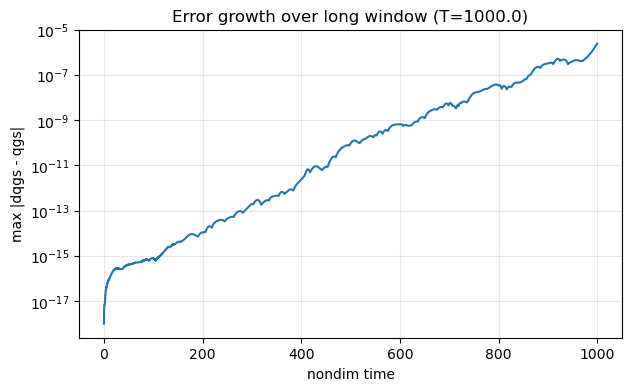

error stays below 1.0 over T=1000.0 (max 2.43e-06)


In [6]:
N_long = 10_000
T_long = N_long * dt

t_qgs_l, traj_qgs_l = integrate_runge_kutta(f_qgs, 0.0, T_long, dt, ic, write_steps=1)
traj_qgs_l = np.asarray(traj_qgs_l).T
traj_jax_l = np.asarray(integrate(f_dqgs, jnp.asarray(ic), dt, N_long))

max_err_l = np.abs(traj_jax_l - traj_qgs_l).max(axis=1)
time_l = np.arange(N_long + 1) * dt

plt.figure(figsize=(7, 4))
plt.semilogy(time_l, np.maximum(max_err_l, 1e-18))
plt.xlabel("nondim time"); plt.ylabel("max |dqgs - qgs|")
plt.title(f"Error growth over long window (T={T_long})")
plt.grid(True, which="both", alpha=0.3); plt.show()

# Time to reach O(1) separation
thresh = 1.0
idx = np.argmax(max_err_l > thresh)
print(f"error exceeds {thresh} at t ~ {time_l[idx]:.0f}" if max_err_l[-1] > thresh
      else f"error stays below {thresh} over T={T_long} (max {max_err_l.max():.2e})")

The error starts at round-off (~1e-17) and climbs roughly exponentially — here
reaching ~1e-6 by `T = 1000` — as a positive Lyapunov exponent amplifies the
round-off-level differences. On a longer window it continues toward O(1)
separation, at which point the two trajectories are effectively independent. This
divergence is the expected behaviour of a chaotic system, not a validation
failure.

## 6. `write_steps` cross-check

The integrator supports qgs-style subsampling: `write_steps=k` records every `k`
steps, on the grid `0, k, 2k, ..., N`. Confirm the subsampled dqgs records equal
(a) the full dqgs run sliced `[::k]`, and (b) the qgs run with the same
`write_steps`.

In [7]:
k = 10
traj_jax_sub = np.asarray(integrate(f_dqgs, jnp.asarray(ic), dt, N, write_steps=k))
print("subsampled shape:", traj_jax_sub.shape, "expected", (N // k + 1, 36))

# (a) matches the full run sliced
print("max |sub - full[::k]| (dqgs):", np.max(np.abs(traj_jax_sub - traj_jax[::k])))

# (b) matches qgs with the same write_steps
_, traj_qgs_sub = integrate_runge_kutta(f_qgs, 0.0, T, dt, ic, write_steps=k)
traj_qgs_sub = np.asarray(traj_qgs_sub).T
print("sub shapes  dqgs:", traj_jax_sub.shape, " qgs:", traj_qgs_sub.shape)
print("max |dqgs_sub - qgs_sub|:", np.max(np.abs(traj_jax_sub - traj_qgs_sub)))

subsampled shape: (11, 36) expected (11, 36)
max |sub - full[::k]| (dqgs): 6.938893903907228e-18
sub shapes  dqgs: (11, 36)  qgs: (11, 36)
max |dqgs_sub - qgs_sub|: 9.194034422677078e-17


## Why no manual threading / multiprocessing?

`qgs` uses Python `multiprocessing` in two places: (1) building the symbolic
inner products at model-build time, and (2) its `RungeKuttaIntegrator` class,
which farms an *ensemble* of trajectories out to worker **processes** to sidestep
the GIL in its numba/Python-dispatched per-step loop.

Neither motivation carries to the JAX implementation:

- A `jit`-ed `integrate` is **one compiled XLA program**; XLA already parallelizes
  the underlying linear algebra across its own threadpool (or a GPU). Hand-rolled
  Python threads would only fight that runtime.
- **RK4 is inherently sequential in time** — each step depends on the previous —
  so the time dimension is unparallelizable in any framework.
- At **36-D the per-step work is tiny**; intra-step threading is pure overhead.
- The only real parallelism is across **independent trajectories** (ensembles),
  and that is `jax.vmap` over the initial condition — a single batched program,
  no processes, no pickling, no GIL.
- Decisively, **parameter recovery differentiates through the entire trajectory**,
  which requires a single traced computation (`lax.scan`). Multiprocessing would
  split that across processes and **break autodiff outright**.

So the integrator is a plain `lax.scan`; scale out with `vmap`, not threads.

## From notebook to automated test

The next step is to distill this into `tests/test_trajectory.py`. The core
assertion is the short-window check from section 4:

```python
assert max_err_per_step.max() < 1e-8   # matched IC/dt/RK4 -> near round-off
```

plus the layer-1 tendency check (section 3) and the `write_steps` consistency
check (section 6). The long-window section is illustrative (chaotic divergence is
expected) and would not be a hard assertion.

In [8]:
assert max_err_per_step.max() < 1e-8, (
    f"short-window trajectory error {max_err_per_step.max():.2e} exceeds 1e-8")
print("VALIDATION PASSED: short-window max error =", f"{max_err_per_step.max():.3e}")

VALIDATION PASSED: short-window max error = 9.194e-17
